# Argo Float Chlorophyll and Satellite Reflectance Comparisons

This notebook will detail how to access and use Argo data to transform the large float dataset into a chlorophyll profile that can be used as input to the biooptical model HydroLight. Once run in HydroLight, you will be able to use the results to compare a variable to that of a satellite.


First, load in your packages

In [26]:
import warnings
warnings.filterwarnings("ignore")

def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [27]:
from argopy import DataFetcher  # This is the class to work with Argo data
from argopy import ArgoIndex  #  This is the class to work with Argo index
from argopy import ArgoColors  # This is a class with useful pre-defined colors
from argopy.plot import scatter_map, scatter_plot  # Makes maps and plots
import argopy
argopy.set_options(src='erddap')
argopy.reset_options()
argopy.clear_cache()
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import xarray as xr
import gsw
import pandas as pd
xr.set_options(display_expand_attrs = False)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4
import openpyxl
from scipy.stats import linregress
import glob
import os

Now we can choose what region and time we want our data from. 

In [3]:
box = [-180, 180, -80, -35, 0,1000, '2025-01-25', '2025-02-01'] #lon1, lon2, lat1, lat2, pressure1, pressure2, start date, end date
f = DataFetcher(ds='bgc', params=['CHLA'], mode='expert').region(box) #choose your parameters
f

<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo BGC data fetcher for a space/time region
🗺  Domain: [x=-180.00/180.00; y=-80.00/-35.00; z=0.0/1000.0; t=2025-01-25/2025-02-01]
🔗 API: https://erddap.ifremer.fr/erddap
📗 Parameters: ['CHLA', 'PRES', 'TEMP', 'PSAL']
📕 BGC 'must be measured' parameters: []
🏄 User mode: expert
🟢 Dataset: bgc-s
🌥  Performances: cache=False, parallel=False

In [4]:
%%time
ds = f.data  # Trigger data fetching and processing
ds.argo

CPU times: user 21.1 s, sys: 424 ms, total: 21.5 s
Wall time: 1min 3s


<xarray.Dataset.argo>
This is a collection of Argo points
N_POINTS(93671) ~ N_PROF(171) x N_LEVELS(1739)

We have our data loaded, so now we can inspect it. N_POINTS is how many measurements were taken. 

In [5]:
ds

<xarray.Dataset> Size: 19MB
Dimensions:                (N_POINTS: 93671)
Coordinates:
    LATITUDE               (N_POINTS) float64 749kB ...
    LONGITUDE              (N_POINTS) float64 749kB ...
    TIME                   (N_POINTS) datetime64[ns] 749kB ...
  * N_POINTS               (N_POINTS) int64 749kB 0 1 2 3 ... 93668 93669 93670
Data variables: (12/30)
    CHLA                   (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED          (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED_ERROR    (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED_QC       (N_POINTS) int64 749kB 9 9 9 9 9 9 9 ... 9 9 9 9 9 1
    CHLA_DATA_MODE         (N_POINTS) <U1 375kB '' '' '' '' ... 'A' 'A' 'A' 'A'
    CHLA_QC                (N_POINTS) int64 749kB 9 9 9 9 9 9 9 ... 9 9 9 9 9 3
    ...                     ...
    TEMP_ADJUSTED          (N_POINTS) float32 375kB ...
    TEMP_ADJUSTED_ERROR    (N_POINTS) float32 375kB ...
    TEMP_ADJUSTED_QC       (N_POINTS) int64 749kB 1 1 1 1 8 1 1 ... 1 1 1 1 4 1
    TEMP_DATA_MODE         (N_POINTS) <U1 375kB 'D' 'D' 'D' 'D' ... 'D' 'D' 'D'
    TEMP_QC                (N_POINTS) int64 749kB 1 1 1 1 8 1 1 ... 1 1 1 1 4 1
    TIME_QC                (N_POINTS) int64 749kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes: (7)

If we would rather see profiles, we can use the following code. This is what we will be using for the rest of the analysis.

In [6]:
data=ds.argo.point2profile()
data

<xarray.Dataset> Size: 29MB
Dimensions:                (N_PROF: 171, N_LEVELS: 1739)
Coordinates:
  * N_PROF                 (N_PROF) int64 1kB 57 163 93 66 87 ... 50 165 26 108
  * N_LEVELS               (N_LEVELS) int64 14kB 0 1 2 3 ... 1735 1736 1737 1738
    LATITUDE               (N_PROF) float64 1kB -62.66 -57.47 ... -62.21 -57.02
    LONGITUDE              (N_PROF) float64 1kB -91.86 0.2293 ... -65.75 95.56
    TIME                   (N_PROF) datetime64[ns] 1kB 2025-01-25T01:18:32 .....
Data variables: (12/30)
    CHLA                   (N_PROF, N_LEVELS) float32 1MB nan nan ... nan nan
    CHLA_ADJUSTED          (N_PROF, N_LEVELS) float32 1MB nan nan ... nan nan
    CHLA_ADJUSTED_ERROR    (N_PROF, N_LEVELS) float32 1MB nan nan ... nan nan
    CHLA_ADJUSTED_QC       (N_PROF, N_LEVELS) int64 2MB 9 9 9 ... 99999 99999
    CHLA_DATA_MODE         (N_PROF) <U1 684B '' 'A' 'A' 'A' ... 'R' 'A' 'R' 'A'
    CHLA_QC                (N_PROF, N_LEVELS) int64 2MB 9 9 9 ... 99999 99999
    ...                     ...
    TEMP_ADJUSTED          (N_PROF, N_LEVELS) float32 1MB 4.482 4.483 ... nan
    TEMP_ADJUSTED_ERROR    (N_PROF, N_LEVELS) float32 1MB 0.002 0.002 ... nan
    TEMP_ADJUSTED_QC       (N_PROF, N_LEVELS) int64 2MB 1 1 1 ... 99999 99999
    TEMP_DATA_MODE         (N_PROF) <U1 684B 'D' 'D' 'D' 'D' ... 'A' 'D' 'D' 'D'
    TEMP_QC                (N_PROF, N_LEVELS) int64 2MB 1 1 1 ... 99999 99999
    TIME_QC                (N_PROF) int64 1kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
Attributes: (8)

These are the variables in our dataset. All of the physical parameters are present and only the paraameter we called out earlier. There is also platform number, which is what our wmo ids will fall under.

In [7]:
ds.data_vars

Data variables:
    CHLA                   (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED          (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED_ERROR    (N_POINTS) float32 375kB ...
    CHLA_ADJUSTED_QC       (N_POINTS) int64 749kB 9 9 9 9 9 9 9 ... 9 9 9 9 9 1
    CHLA_DATA_MODE         (N_POINTS) <U1 375kB '' '' '' '' ... 'A' 'A' 'A' 'A'
    CHLA_QC                (N_POINTS) int64 749kB 9 9 9 9 9 9 9 ... 9 9 9 9 9 3
    CONFIG_MISSION_NUMBER  (N_POINTS) int64 749kB 285 285 285 285 ... 33 33 33
    CYCLE_NUMBER           (N_POINTS) int64 749kB 285 285 285 285 ... 33 33 33
    DIRECTION              (N_POINTS) <U1 375kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A'
    PLATFORM_NUMBER        (N_POINTS) int64 749kB 5905096 5905096 ... 5907052
    POSITION_QC            (N_POINTS) int64 749kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    PRES                   (N_POINTS) float32 375kB ...
    PRES_ADJUSTED          (N_POINTS) float32 375kB ...
    PRES_ADJUSTED_ERROR    (N_POINTS) float32 375kB ...
    PRES_ADJ

Argopy has a lot of easy to use features for plotting. The following line will show us the points each profile was taken.

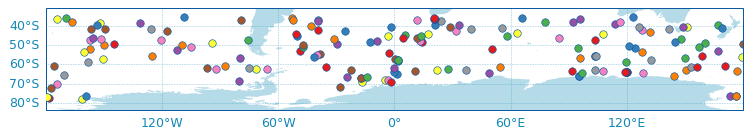

In [8]:
f.plot('trajectory', add_legend=False);

Another way that we can go about getting data from argopy is by using the index function. 

In [9]:
# Load the index and select profiles in a given box:
idx = ArgoIndex(index_file='bgc-s', params='CHLA').query.box([-180, 180, -80, -35, '2025-01-25', '2025-02-01'])
idx

<argoindex.pyarrow>
Host: https://data-argo.ifremer.fr
Index: argo_synthetic-profile_index.txt.gz
Convention: argo_synthetic-profile_index (Synthetic-Profile directory file of the Argo GDAC)
In memory: True (389302 records)
Searched: True (171 matches, 0.0439%) - {'BOX': [-180, 180, -80, -35, '2025-01-25', '2025-02-01']}

In [10]:
print(f"Found {len(idx.read_wmo())} floats / {idx.N_MATCH} profiles in this selection")

Found 157 floats / 171 profiles in this selection


To see this data, we can turn it into a pandas dataframe.

In [11]:
df = idx.to_dataframe()
df.head()

,file,date,latitude,longitude,ocean,profiler_code,institution,parameters,parameter_data_mode,date_update,wmo,cyc,institution_name,dac,profiler
0,aoml/1902494/profiles/SD1902494_037.nc,2025-01-25 08:12:14,-48.570,14.023,A,869,AO,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,AAAAAAARDD,2025-12-22 23:00:58,1902494,37,"AOML, USA",aoml,NAVIS_EBR
1,aoml/1902643/profiles/SD1902643_034.nc,2025-01-25 23:16:06,-47.003,148.116,P,846,AO,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,DDDDAAADD,2026-03-26 10:07:19,1902643,34,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
2,aoml/1902651/profiles/SD1902651_034.nc,2025-01-29 07:01:23,-39.279,113.834,I,846,AO,PRES TEMP PSAL DOXY CHLA BBP700 PH_IN_SITU_TOT...,DDDDAADDRRRR,2025-12-24 03:18:03,1902651,34,"AOML, USA",aoml,Teledyne Webb Research float with SBE conducti...
3,aoml/1902718/profiles/SD1902718_003.nc,2025-01-26 00:54:48,-41.651,-156.769,P,869,AO,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,AAAAAAARDD,2026-03-27 16:25:54,1902718,3,"AOML, USA",aoml,NAVIS_EBR
4,aoml/1902719/profiles/SD1902719_008.nc,2025-01-28 15:40:12,-47.559,-157.257,P,869,AO,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,AAAAAAARDD,2026-03-29 10:04:13,1902719,8,"AOML, USA",aoml,NAVIS_EBR


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   file                 171 non-null    object       
 1   date                 171 non-null    datetime64[s]
 2   latitude             171 non-null    float64      
 3   longitude            171 non-null    float64      
 4   ocean                171 non-null    object       
 5   profiler_code        171 non-null    int64        
 6   institution          171 non-null    object       
 7   parameters           171 non-null    object       
 8   parameter_data_mode  171 non-null    object       
 9   date_update          171 non-null    datetime64[s]
 10  wmo                  171 non-null    int64        
 11  cyc                  171 non-null    int64        
 12  institution_name     171 non-null    object       
 13  dac                  171 non-null    object       

This is a function that can be used to correctly format and make chlorophyll profiles for HydroLight input.

In [13]:
def process_float_chl_depth(data, float_id, root):

    #To make sure the dimensions of the arrays will be correct, we can use the following lines.
    pres = np.atleast_2d(data['PRES_ADJUSTED'].values)
    chl  = np.atleast_2d(data['CHLA_ADJUSTED'].values)
    lat  = np.atleast_1d(data['LATITUDE'].values)

    #This ensures that the latitude will be the same shape as the pressure.
    if lat.ndim == 1:
        lat = lat[:, np.newaxis]
        
    #Now we can build the dataframe
    dfs = []
    #using this loop will make sure that the arrays will be same length. 
    for i in range(pres.shape[0]):

        depth_i = -gsw.conversions.z_from_p(pres[i, :], lat[i]) #gsw converts pressure to depth. HydroLight requires depth profiles, not pressure profiles
        chl_i   = chl[i, :]

        df_i = pd.DataFrame({
        'Depth(m)': depth_i,
        'ChlA': chl_i
        })

        dfs.append(df_i)

    chl_depth_df = pd.concat(dfs, ignore_index=True)
    df_cleaned = chl_depth_df.dropna() #drop nan values


    # Save file
    df_hl = df_cleaned[['Depth(m)', 'ChlA']].copy()
    
    # Make sure that depth increases downwards
    df_hl = df_hl.sort_values('Depth(m)')

    # Precaution that removes negative depths if present
    df_hl = df_hl[df_hl['Depth(m)'] >= 0]
    
    # Prevent file from saving if no data is present after dropping nans, etc.
    if df_hl.empty:
        print(f"No valid chlorophyll data for float {float_id}. File not created.")
        return

    # HydroLight format requires begin header, end header, and end data lines
    begin_header = '/begin_header'
    end_header = '/end_header'
    end_data = '/end_data'

    # name the file
    output_filename = f'float_{float_id}_chl_profile.txt'
    output_filepath = root + output_filename
    
    #write the headings/endings
    with open(output_filepath, 'w', encoding='ascii', newline='') as f:
        f.write(f"{begin_header}\n")  
        f.write(f"{end_header}\r\n")
    
        for depth, chl in zip(df_hl['Depth(m)'], df_hl['ChlA']):
            f.write(f"{depth:.3f} {chl:.6f}\n")
            
        f.write(f"{end_data}")

    print(f"HydroLight chlorophyll profile saved to: {output_filename}")

This for loop runs the function for each profile taken in the "box" we defined at the beginning of the notebook.

In [16]:
for wmo, float_ds in ds.groupby("PLATFORM_NUMBER"):

    try:
        process_float_chl_depth(
            data=float_ds,
            float_id=int(wmo),
            root="/Users/jessdefeo/Desktop/argodata/"
        )
    except Exception as e:
        print(f"Skipping {wmo}: {e}")

HydroLight chlorophyll profile saved to: float_1902494_chl_profile.txt
HydroLight chlorophyll profile saved to: float_1902593_chl_profile.txt
HydroLight chlorophyll profile saved to: float_1902643_chl_profile.txt
HydroLight chlorophyll profile saved to: float_1902651_chl_profile.txt
No valid chlorophyll data for float 1902662. File not created.
No valid chlorophyll data for float 1902686. File not created.
HydroLight chlorophyll profile saved to: float_1902718_chl_profile.txt
HydroLight chlorophyll profile saved to: float_1902719_chl_profile.txt
HydroLight chlorophyll profile saved to: float_1902741_chl_profile.txt
HydroLight chlorophyll profile saved to: float_2902299_chl_profile.txt
No valid chlorophyll data for float 2902825. File not created.
No valid chlorophyll data for float 2902827. File not created.
No valid chlorophyll data for float 2902829. File not created.
No valid chlorophyll data for float 2902830. File not created.
No valid chlorophyll data for float 2902831. File not 

Now we can run HydroLight!

## Satellite Data

Load in satellite data attained from https://search.earthdata.nasa.gov/search. This NASA website allows you to filter and download satellite data. For this study, we will be using the weekly average of Kd from PACE at 490nm at 4km resolution. 

In [14]:
da = xr.open_dataset('/Users/jessdefeo/Downloads/PACE_OCI.20250125_20250201.L3m.8D.KD.V3_1.Kd.4km.nc')
da

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 4320, lon: 8640, wavelength: 17, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 136B 400.0 413.0 425.0 ... 678.0 701.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Kd          (lat, lon, wavelength) float32 3GB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (64)

Let's use Argopy again to select exactly which floats and the correct cycle number we ran in HydroLight so that we can get the lat/lon.

In [37]:
S2903833 = f.profile(2903833, 13).to_xarray()
S7900970 = f.profile(7900970, 2).to_xarray()
S7902141 = f.profile(7902141, 4).to_xarray()
S6990670 = f.profile(6990670, 2).to_xarray()
S2903832 = f.profile(2903832, 28).to_xarray()
S7900693 = f.profile(7900693, 2).to_xarray()
S7902135 = f.profile(7902135, 4).to_xarray()
S5905583 = f.profile(5905583, 13).to_xarray()
S1902718 = f.profile(1902718, 3).to_xarray()
S7902143 = f.profile(7902143, 3).to_xarray()

Create a dictionary of the wmoid and the data.

In [38]:
wmoid = {
    '2903833': S2903833, 
    '7900970': S7900970,
    '7902141': S7902141,
    '6990670': S6990670,
    '2903832': S2903832,
    '7900693': S7900693,
    '7902135': S7902135,
    '5905583': S5905583,
    '1902718': S1902718,
    '7902143': S7902143}

The following function is how we average our satellite data. The satellite data lat/lon will not match the float location exactly, so we average it over a box that includes the float's location. This function is done for each float location so we can get a corresponding satellite Kd value. 

In [39]:
def extract_sat_kd490(da, data_dict, window=0.1):
    results = []

    for profile_id, data in data_dict.items():

        # chooses the first lat/lon value since they are the same throughout the profile
        lat = float(data['LATITUDE'].values[0])
        lon = float(data['LONGITUDE'].values[0])

        #window is 0.1 degrees. PACE has different wavelenghts that it uses so we have to isolate the one we want.
        subset = da.Kd.sel(
            lat=slice(lat + window, lat - window),
            lon=slice(lon - window, lon + window),
            wavelength=490.0
        )

        df = subset.to_dataframe().dropna() #drop nan
        mean_val = df['Kd'].mean()  #take the mean
    #put all together
        results.append({
            'profile_id': profile_id,
            'LATITUDE': lat,
            'LONGITUDE': lon,
            'sat kd': mean_val
        })
#make dataframe
    return pd.DataFrame(results)

The following code calls the function. It will show us the satellite Kd averaged over our window as well as the mean lat/lon.

In [40]:
for d in wmoid:
    try:
        df_sat = extract_sat_kd490(da, wmoid) #da is the satellite data we loaded in and wmoid is dictionary from above
    
        
    except Exception as e:
        print(f"Skipping {wmo}: {e}")

df_sat

,profile_id,LATITUDE,LONGITUDE,sat kd
0,2903833,-30.142360,-106.421790,0.024264
1,7900970,-76.241827,176.383303,0.189192
2,7902141,-41.131200,55.715000,0.053904
3,6990670,-37.124523,-52.428536,0.034090
4,2903832,-29.113650,-89.991500,0.025928
5,7900693,-76.890473,-179.493387,0.149400
6,7902135,-41.756700,-138.070600,0.031704
7,5905583,-38.139000,116.443000,0.041088
8,1902718,-41.651300,-156.768900,0.040168
9,7902143,-63.783300,-0.353500,0.048089


## HydroLight Outputs

This loop will allow us to open each single wavelength output file (the S files) in our folder and calculates the mean over the top 5m. 

In [41]:
folder_path = '/Users/jessdefeo/Documents/HE60/output/HydroLight/excel/2025floats/S*.xlsx' #change based on your path

In [42]:
rows = []

for file_path in glob.glob(folder_path):
    file_name = os.path.basename(file_path) 
    profile_id = int(''.join(filter(str.isdigit, file_name))) #changes the variable name to just wmoid, gets rid of file naming

    sheet = pd.read_excel(file_path, sheet_name='K funcs', skiprows=2) #reads in file

    kd = sheet['K_d'].drop(index=0) #formatting
    kd_avg = kd.iloc[:6].mean() #mean of top 5m

    rows.append({'profile_id': profile_id, 'float kd': kd_avg})

df_float = pd.DataFrame(rows)
df_float

,profile_id,float kd
0,7902141,0.069190
1,2903832,0.031157
2,7900970,0.296188
3,2903833,0.022591
4,1902718,0.031468
5,5905583,0.060023
6,7902135,0.027057
7,7900693,0.267963
8,7902143,0.060894
9,6990670,0.033141


To combine the dataframes, we have to make sure that the joining column is in the same format. The following lines make profile_id into an integer for both satellite and float.

In [43]:
df_sat['profile_id'] = df_sat['profile_id'].astype(int)
df_float['profile_id'] = df_float['profile_id'].astype(int)

The dataframes can be merged. 

In [44]:
df_merged = pd.merge(df_sat, df_float, on='profile_id', how='inner')
df_merged

,profile_id,LATITUDE,LONGITUDE,sat kd,float kd
0,2903833,-30.142360,-106.421790,0.024264,0.022591
1,7900970,-76.241827,176.383303,0.189192,0.296188
2,7902141,-41.131200,55.715000,0.053904,0.069190
3,6990670,-37.124523,-52.428536,0.034090,0.033141
4,2903832,-29.113650,-89.991500,0.025928,0.031157
5,7900693,-76.890473,-179.493387,0.149400,0.267963
6,7902135,-41.756700,-138.070600,0.031704,0.027057
7,5905583,-38.139000,116.443000,0.041088,0.060023
8,1902718,-41.651300,-156.768900,0.040168,0.031468
9,7902143,-63.783300,-0.353500,0.048089,0.060894


The data is now in a form that can be easily analyzed and plot as seen below. 

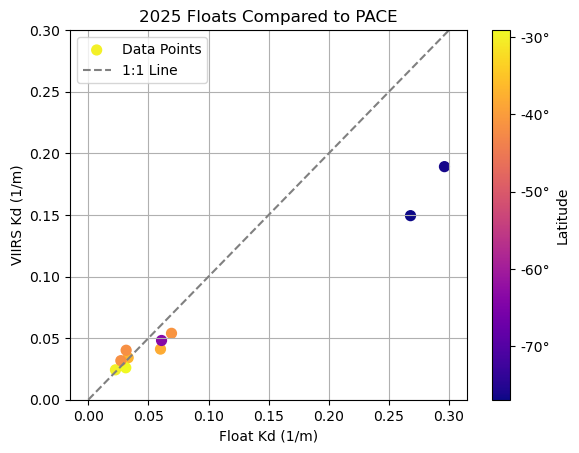

In [45]:
plt.scatter(df_merged['float kd'], df_merged['sat kd'], s=50, label='Data Points', c=df_merged.LATITUDE, cmap='plasma')
cbar = plt.colorbar(ticks=[-70, -60, -50, -40, -30], label='Latitude')
cbar.set_ticklabels(['-70°', '-60°', '-50°', '-40°', '-30°'])
x_points = np.array([0, 0.1, 0.2, 0.3])
y_points = np.array([0, 0.1, 0.2, 0.3])
plt.plot(x_points, y_points, c='gray', label='1:1 Line', linestyle='dashed')


plt.ylim(0,0.3)
plt.xlabel('Float Kd (1/m)')
plt.ylabel('VIIRS Kd (1/m)')

plt.grid()
plt.legend(loc='upper left');
plt.title('2025 Floats Compared to PACE');